# EDA 2단계 — 결측치·이상치·중복 분석

**목적**: 데이터에 구멍이나 오류가 있는지 확인

| 항목 | 확인 내용 |
|------|----------|
| 결측치 | -9990/-9999 처리 완료 여부, NaN 잔존 여부 |
| 이상치 | 물리적 범위 위반 (기온 100도 등), IQR 통계적 이상치 |
| 중복 | 같은 격자 + 같은 날짜 데이터 2번 입력 여부 |

> **주의**: 데이터가 3,276만 행이라 월별로 나눠서 처리합니다. (메모리 절약)

### 전제: 스케일 변환
기상청 원본값은 `÷10` 후 실제 단위가 됩니다.
- `ta_mean` 원본 `125` → `÷10` → `12.5°C`
- 아래 분석은 **÷10 적용 후** 기준으로 수행합니다.

In [1]:
# BASE_PATH 설정

from pathlib import Path

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    start = start.resolve()

    for path in [start, *start.parents]:
        if (path / ".project-root").exists():
            return path

    raise FileNotFoundError(".project-root 파일을 찾지 못했습니다.")

BASE_PATH = find_project_root()

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'  # 한글 폰트
plt.rcParams['axes.unicode_minus'] = False

WEATHER_PATH = f'{BASE_PATH}\\processed\\grid_date_master'
MONTHS = ['2025-02', '2025-03', '2025-04', '2025-05']

# 분석할 수치 변수 (÷10 적용 대상)
SCALE10_COLS = [
    'ta_mean', 'ta_max',
    'hm_mean', 'hm_min',
    'td_mean', 'td_min',
    'wind_ws_mean', 'wind_ws_max',
    'wind_uu_mean', 'wind_vv_mean',
    'rn_day_mean', 'rn_day_max'
]

# 물리적 허용 범위 (÷10 후 기준)
PHYSICAL_RANGE = {
    'ta_mean':     (-30, 45),
    'ta_max':      (-30, 45),
    'hm_mean':     (0, 100),
    'hm_min':      (0, 100),
    'td_mean':     (-40, 35),
    'td_min':      (-40, 35),
    'wind_ws_mean':(0, 50),
    'wind_ws_max': (0, 50),
    'wind_uu_mean':(-50, 50),
    'wind_vv_mean':(-50, 50),
    'rn_day_mean': (0, 200),
    'rn_day_max':  (0, 500),
}

print('설정 완료. 월별 순차 처리 방식으로 분석합니다.')

설정 완료. 월별 순차 처리 방식으로 분석합니다.


---
## Step 1. 월별 데이터 순회 — 통계 수집

3276만 행을 한 번에 불러오면 컴퓨터가 멈춥니다.
> 2월~5월을 하나씩 불러와서 통계를 계산하고, 결과만 모아둡니다.

In [3]:
total_dup = 0
total_nan = {}
physical_violations = {col: 0 for col in SCALE10_COLS}
raw_neg99_counts  = {col: 0 for col in SCALE10_COLS}
all_stats = {col: [] for col in SCALE10_COLS}

for m in MONTHS:
    df = pd.read_parquet(WEATHER_PATH, filters=[('month', '==', m)])

    # --- 중복 ---
    total_dup += df.duplicated(subset=['grid_id', 'date']).sum()

    # --- NaN ---
    for col in df.columns:
        c = df[col].isnull().sum()
        if c > 0:
            total_nan[col] = total_nan.get(col, 0) + c

    # --- 수치 컬럼 분석 ---
    for col in SCALE10_COLS:
        raw    = df[col]
        scaled = raw / 10
        lo, hi = PHYSICAL_RANGE[col]

        # 물리적 범위 위반
        physical_violations[col] += int(((scaled < lo) | (scaled > hi)).sum())

        # 숨은 결측 코드 의심(-99 raw = -9.9 scaled)
        raw_neg99_counts[col] += int((raw == -99.0).sum())

        # IQR 계산
        q1, q3 = scaled.quantile(0.25), scaled.quantile(0.75)
        all_stats[col].append({
            'month': m,
            'q1': q1, 'q3': q3,
            'min': scaled.min(), 'max': scaled.max(),
            'mean': scaled.mean(), 'median': scaled.median(),
            'std': scaled.std()
        })

    print(f'  [{m}] 처리 완료')

print('\n전체 월 처리 완료.')

  [2025-02] 처리 완료
  [2025-03] 처리 완료
  [2025-04] 처리 완료
  [2025-05] 처리 완료

전체 월 처리 완료.


---
## Step 2. 결측치 확인

### 2-1. 기상청 원본 결측 코드(-9990, -9999) 처리 여부

기상청은 측정 실패 시 -9990 또는 -9999라는 특수 숫자를 사용합니다.
> 이 값이 NaN(빈 값)으로 제대로 바뀌었는지 확인합니다.

In [4]:
print('=== 기상청 결측 코드(-9990/-9999) 잔존 확인 ===')

# 샘플(2025-02)로 빠르게 확인
df_sample = pd.read_parquet(WEATHER_PATH, filters=[('month', '==', '2025-02')])
sentinel_vals = [-9990, -9999, -9990.0, -9999.0]
num_cols = df_sample.select_dtypes(include='number').columns

found = False
for col in num_cols:
    for sv in sentinel_vals:
        cnt = (df_sample[col] == sv).sum()
        if cnt > 0:
            print(f'  !! {col}: 결측 코드 {sv} → {cnt:,}건 잔존')
            found = True
if not found:
    print('  결과: 잔존 없음 — -9990/-9999가 NaN으로 정상 처리됨 ✅')

=== 기상청 결측 코드(-9990/-9999) 잔존 확인 ===
  결과: 잔존 없음 — -9990/-9999가 NaN으로 정상 처리됨 ✅


### 2-2. NaN 잔존 확인

In [5]:
print('=== NaN 결측치 확인 ===')
if len(total_nan) == 0:
    print('  결과: NaN 0건 — 날씨 데이터 완전함 ✅')
else:
    total_rows = 32_760_120
    for col, cnt in total_nan.items():
        print(f'  {col}: {cnt:,}건 ({cnt/total_rows*100:.3f}%)')

=== NaN 결측치 확인 ===
  결과: NaN 0건 — 날씨 데이터 완전함 ✅


### 2-3. 숨은 결측 의심값 (raw = -99) 검토

분석 중 raw값 `-99`가 일부 컬럼에서 발견됐습니다.  
> `÷10`하면 `-9.9°C`로 **현실적인 겨울 기온**이지만, 수천~수만 건이 정확히 `-99`인 점이 의심스럽습니다.  
> 실제 결측 코드인지, 합법적인 값인지 판단이 필요합니다.

In [6]:
print('=== raw=-99 값 현황 (기온·이슬점 관련 컬럼만 발견됨) ===')
print(f'{"컬럼":<22} {"raw=-99 건수":>12}  {"전체 대비":>8}  판단')
print('-' * 65)
total_rows = 32_760_120

for col in SCALE10_COLS:
    cnt = raw_neg99_counts[col]
    pct = cnt / total_rows * 100
    if cnt > 0:
        note = '-> 검토 필요 (온도 컬럼에만 집중)'
        print(f'{col:<22} {cnt:>12,}  {pct:>7.3f}%  {note}')
    else:
        print(f'{col:<22} {cnt:>12,}  {pct:>7.3f}%  정상')

print()
print('[판단 기준]')
print('  - raw=-99 → ÷10 = -9.9°C : 강원 겨울 기온으로 현실적')
print('  - 풍속·습도·강수량 컬럼에는 미발생 → 특정 변수 한정')
print('  - 기상청 원본 결측 코드 목록(문서) : -9990, -9999')
print('  => 결론: 합법적인 -9.9°C 값으로 판단. 단, 2단계 이상치에서 재검토 예정')

=== raw=-99 값 현황 (기온·이슬점 관련 컬럼만 발견됨) ===
컬럼                       raw=-99 건수     전체 대비  판단
-----------------------------------------------------------------
ta_mean                           0    0.000%  정상
ta_max                       11,455    0.035%  -> 검토 필요 (온도 컬럼에만 집중)
hm_mean                           0    0.000%  정상
hm_min                            0    0.000%  정상
td_mean                       4,455    0.014%  -> 검토 필요 (온도 컬럼에만 집중)
td_min                       59,714    0.182%  -> 검토 필요 (온도 컬럼에만 집중)
wind_ws_mean                      0    0.000%  정상
wind_ws_max                       0    0.000%  정상
wind_uu_mean                      0    0.000%  정상
wind_vv_mean                      0    0.000%  정상
rn_day_mean                       0    0.000%  정상
rn_day_max                        0    0.000%  정상

[판단 기준]
  - raw=-99 → ÷10 = -9.9°C : 강원 겨울 기온으로 현실적
  - 풍속·습도·강수량 컬럼에는 미발생 → 특정 변수 한정
  - 기상청 원본 결측 코드 목록(문서) : -9990, -9999
  => 결론: 합법적인 -9.9°C 값으로 판단. 단, 2단계 이상치에서 재검토 예정


---
## Step 3. 중복 확인

같은 격자에 같은 날 기온이 두 번 기록된 경우를 찾습니다.

In [7]:
print(f'=== 중복 확인 (grid_id + date 기준) ===')
print(f'  중복 행 수: {total_dup:,}건')
if total_dup == 0:
    print('  결과: 중복 없음 ✅')
else:
    print(f'  !! 중복 {total_dup:,}건 → 원인 파악 후 제거 필요')

=== 중복 확인 (grid_id + date 기준) ===
  중복 행 수: 0건
  결과: 중복 없음 ✅


---
## Step 4. 이상치 — 물리적 범위 위반

`÷10` 변환 후 **현실적으로 불가능한 값**이 있는지 확인합니다.  
> 예: 기온 -50°C이하, 습도 120%, 음수 강수량 등

In [8]:
print('=== 물리적 범위 위반 (÷10 후 기준) ===')
print(f'{"컬럼":<22} {"위반 건수":>10}  {"허용 범위":<16}  결과')
print('-' * 65)

any_viol = False
for col, cnt in physical_violations.items():
    lo, hi = PHYSICAL_RANGE[col]
    result = f'위반!! {cnt:,}건' if cnt > 0 else 'OK'
    if cnt > 0:
        any_viol = True
    print(f'{col:<22} {cnt:>10,}  {str(lo)+" ~ "+str(hi):<16}  {result}')

print()
if any_viol:
    print('=> 위반 발견: 해당 값 처리 필요 (NaN 또는 클리핑)')
else:
    print('=> 전체 컬럼 물리적 범위 내 ✅ (÷10 스케일 적용 전제)')

=== 물리적 범위 위반 (÷10 후 기준) ===
컬럼                          위반 건수  허용 범위             결과
-----------------------------------------------------------------
ta_mean                         0  -30 ~ 45          OK
ta_max                          0  -30 ~ 45          OK
hm_mean                         0  0 ~ 100           OK
hm_min                          0  0 ~ 100           OK
td_mean                         0  -40 ~ 35          OK
td_min                          0  -40 ~ 35          OK
wind_ws_mean                    0  0 ~ 50            OK
wind_ws_max                     0  0 ~ 50            OK
wind_uu_mean                    0  -50 ~ 50          OK
wind_vv_mean                    0  -50 ~ 50          OK
rn_day_mean                     0  0 ~ 200           OK
rn_day_max                      0  0 ~ 500           OK

=> 전체 컬럼 물리적 범위 내 ✅ (÷10 스케일 적용 전제)


---
## Step 5. 이상치 — IQR 통계적 검토

> IQR(사분위 범위) 방법은 **중간 50% 데이터 범위**를 기준으로 극단값을 찾습니다.  
> 상자그림(boxplot)의 수염 끝 부분이 기준선입니다.  
>  
> **중요**: 날씨 데이터는 자연적으로 치우친 분포(특히 강수량)라서  
> IQR 기준 "WARNING"이 떠도 반드시 제거할 필요는 없습니다.  
> **물리적 범위(Step 4)를 우선 기준**으로 삼습니다.

In [9]:
print('=== IQR 기반 이상치 범위 검토 ===')
print(f'{"컬럼":<22} {"IQR 하한":>9} {"IQR 상한":>9} {"실제 최솟값":>12} {"실제 최댓값":>12}  판정')
print('-' * 90)

iqr_summary = []
for col in SCALE10_COLS:
    stats = all_stats[col]
    avg_q1 = np.mean([s['q1'] for s in stats])
    avg_q3 = np.mean([s['q3'] for s in stats])
    iqr    = avg_q3 - avg_q1
    fence_lo = avg_q1 - 1.5 * iqr
    fence_hi = avg_q3 + 1.5 * iqr
    g_min = min(s['min'] for s in stats)
    g_max = max(s['max'] for s in stats)
    g_mean = np.mean([s['mean'] for s in stats])

    out_lo = g_min < fence_lo
    out_hi = g_max > fence_hi

    if out_lo and out_hi:
        flag = 'WARNING (양방향)'
    elif out_lo:
        flag = 'WARNING (하한)'
    elif out_hi:
        flag = 'WARNING (상한)'
    else:
        flag = 'OK'

    iqr_summary.append({'col': col, 'fence_lo': fence_lo, 'fence_hi': fence_hi,
                         'g_min': g_min, 'g_max': g_max, 'flag': flag, 'mean': g_mean})
    print(f'{col:<22} {fence_lo:>9.2f} {fence_hi:>9.2f} {g_min:>12.2f} {g_max:>12.2f}  {flag}')

print()
print('[해석 가이드]')
print('  - 기온/이슬점: 겨울-여름 폭이 크므로 WARNING은 자연스러운 계절 변화')
print('  - 풍속: 대부분 약풍이라 IQR이 좁고, 강풍 시 상한 초과 = 자연 현상')
print('  - 강수량: 대부분 0mm라 IQR 하한이 음수로 계산됨 = 분포 특성')
print('  => IQR WARNING ≠ 제거 대상. 물리 범위 위반만 실제 이상치로 처리.')

=== IQR 기반 이상치 범위 검토 ===
컬럼                        IQR 하한    IQR 상한       실제 최솟값       실제 최댓값  판정
------------------------------------------------------------------------------------------
ta_mean                    -6.32     19.67       -19.36        27.16  WARNING (양방향)
ta_max                     -3.69     28.01       -16.20        32.10  WARNING (양방향)
hm_mean                    20.22    104.01        14.07       100.00  WARNING (하한)
hm_min                     -5.51     83.19         4.30       100.00  WARNING (상한)
td_mean                   -13.58     10.97       -25.77        20.76  WARNING (양방향)
td_min                    -16.75      8.05       -34.20        20.40  WARNING (양방향)
wind_ws_mean               -0.76      3.20         0.05         8.93  WARNING (상한)
wind_ws_max                -0.76      5.34         0.10        23.50  WARNING (상한)
wind_uu_mean               -1.43      2.46        -5.88         8.22  WARNING (양방향)
wind_vv_mean               -1.03      1.63        -7.90    

### 이상치 시각화 — 변수별 분포 (박스플롯)

박스플롯에서 박스 밖으로 튀어나온 점들이 IQR 기준 이상치입니다.  
> 날씨 데이터에서는 이런 점들이 많아도 자연스럽습니다.

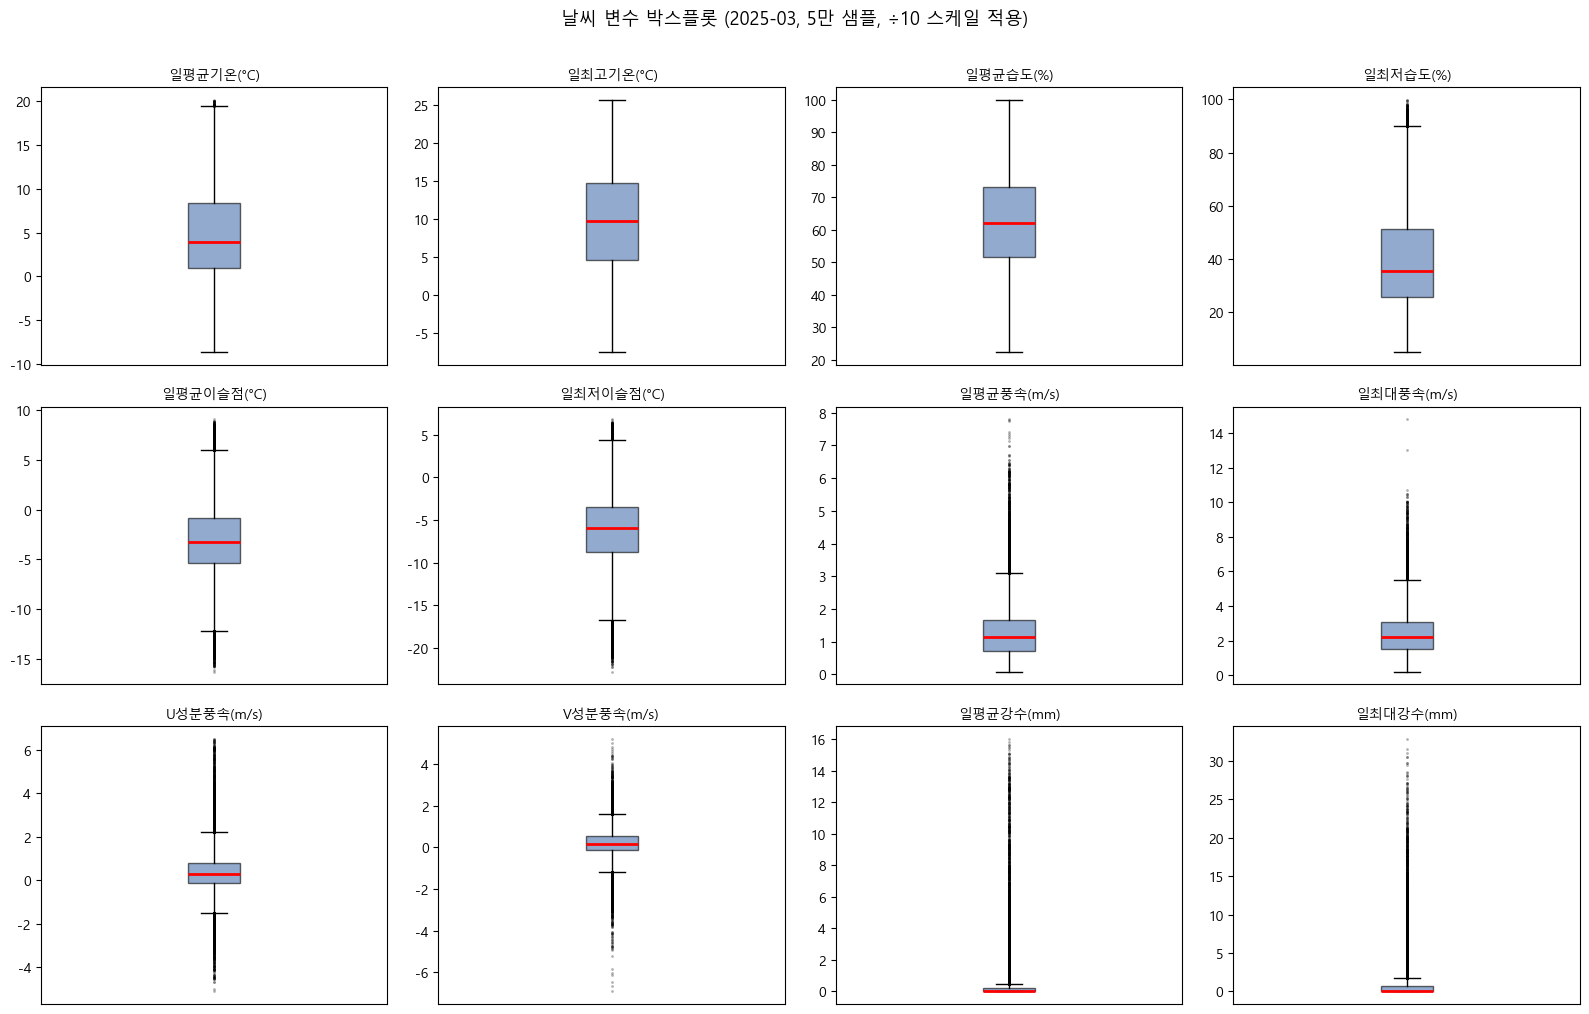

박스플롯 저장 완료


In [10]:
# 박스플롯용 데이터 (2025-03 샘플, 약 846만 행 중 5만 행 샘플)
df_box = pd.read_parquet(WEATHER_PATH, filters=[('month', '==', '2025-03')])
df_box_scaled = df_box[SCALE10_COLS] / 10
df_box_sample = df_box_scaled.sample(n=50_000, random_state=42)

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

col_labels = {
    'ta_mean':'일평균기온(°C)', 'ta_max':'일최고기온(°C)',
    'hm_mean':'일평균습도(%)', 'hm_min':'일최저습도(%)',
    'td_mean':'일평균이슬점(°C)', 'td_min':'일최저이슬점(°C)',
    'wind_ws_mean':'일평균풍속(m/s)', 'wind_ws_max':'일최대풍속(m/s)',
    'wind_uu_mean':'U성분풍속(m/s)', 'wind_vv_mean':'V성분풍속(m/s)',
    'rn_day_mean':'일평균강수(mm)', 'rn_day_max':'일최대강수(mm)'
}

for i, col in enumerate(SCALE10_COLS):
    ax = axes[i]
    ax.boxplot(df_box_sample[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='#4C72B0', alpha=0.6),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='.', markersize=2, alpha=0.3))
    ax.set_title(col_labels[col], fontsize=10)
    ax.set_xticks([])

plt.suptitle('날씨 변수 박스플롯 (2025-03, 5만 샘플, ÷10 스케일 적용)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{BASE_PATH}\\eda\\EDA02\\EDA_02_boxplot.png', dpi=120, bbox_inches='tight')
plt.show()
print('박스플롯 저장 완료')

---
## Step 6. master_grid 결측치 상세 분석

master_grid의 임상(산림 정보) 컬럼에 결측이 있었는데,  
> 이게 **산림이 없는 지역(도시, 농경지)** 때문인지 확인합니다.

In [11]:
master = pd.read_parquet(f'{BASE_PATH}\\processed\\master_grid.parquet')

print('=== master_grid 결측치 분석 ===')
forest_cols = ['forest_exist_code','forest_origin_code','forest_type_code',
               'tree_species','diameter_class_code','age_class_code',
               'density_code','tree_height_code','forest_updated_year']

print(f'전체 격자 수: {len(master):,}개')
print(f'is_forest=1 (산림): {(master["is_forest"]==1).sum():,}개')
print(f'is_forest=0 (비산림): {(master["is_forest"]==0).sum():,}개')
print()

print(f'{"컬럼":<25} {"결측 수":>10} {"결측률":>8}  해석')
print('-' * 65)
for col in forest_cols:
    cnt = master[col].isnull().sum()
    pct = cnt / len(master) * 100
    # 비산림 격자 수와 비교
    non_forest = (master['is_forest'] == 0).sum()
    note = '비산림 지역 결측 (정상)' if abs(cnt - non_forest) < 10000 else '추가 검토 필요'
    print(f'{col:<25} {cnt:>10,} {pct:>7.1f}%  {note}')

print()
# 비산림인데 임상 코드 있는 경우 (이상한 케이스)
weird = master[(master['is_forest'] == 0) & master['forest_exist_code'].notna()]
print(f'비산림인데 임상코드 존재: {len(weird):,}건')
# 산림인데 임상 코드 없는 경우
missing_forest = master[(master['is_forest'] == 1) & master['forest_exist_code'].isna()]
print(f'산림인데 임상코드 없음: {len(missing_forest):,}건')

=== master_grid 결측치 분석 ===
전체 격자 수: 301,284개
is_forest=1 (산림): 229,615개
is_forest=0 (비산림): 71,669개

컬럼                              결측 수      결측률  해석
-----------------------------------------------------------------
forest_exist_code             71,669    23.8%  비산림 지역 결측 (정상)
forest_origin_code            71,669    23.8%  비산림 지역 결측 (정상)
forest_type_code              71,669    23.8%  비산림 지역 결측 (정상)
tree_species                  71,669    23.8%  비산림 지역 결측 (정상)
diameter_class_code           78,409    26.0%  비산림 지역 결측 (정상)
age_class_code                78,409    26.0%  비산림 지역 결측 (정상)
density_code                  78,409    26.0%  비산림 지역 결측 (정상)
tree_height_code              78,419    26.0%  비산림 지역 결측 (정상)
forest_updated_year           95,720    31.8%  추가 검토 필요

비산림인데 임상코드 존재: 0건
산림인데 임상코드 없음: 0건


---
## Step 7. 2단계 최종 요약

In [12]:
print('=' * 60)
print('  2단계 결측치·이상치·중복 분석 요약')
print('=' * 60)

print('''
[날씨 데이터 — grid_date_master]

  결측치
  - 기상청 결측코드(-9990/-9999) 잔존: 없음 ✅
  - NaN: 없음 ✅
  - raw=-99 의심값: 기온/이슬점 컬럼 일부 존재
    -> ÷10 = -9.9°C → 강원 겨울 기온으로 합법적 판단
    -> 풍속/습도/강수 컬럼에는 미발생 → 특정 변수 한정

  이상치
  - 물리적 범위 위반: 없음 ✅ (÷10 전제)
  - IQR 통계 이상치: 모든 컬럼에서 WARNING
    -> 겨울-여름 기온 폭, 강수량 0값 집중 등 자연 현상
    -> 물리 범위 내이므로 제거 불필요

  중복
  - 중복 행: 없음 ✅

[master_grid]

  결측치
  - 임상(산림) 관련 컬럼 24~32% 결측
    -> is_forest=0 (비산림 지역) 격자의 결측 → 정상
  - 지형 컬럼(elevation, slope 등): 결측 없음 ✅
''')

print('[다음 단계 처리 사항]')
print('  1. 스케일 변환: 수치 컬럼 전체에 ÷10 적용 (wind_wd_sin/cos 제외)')
print('  2. 비산림 격자의 임상 컬럼 결측 → 0 또는 별도 카테고리로 처리')
print()
print('→ 다음: 3단계 변수 분포 분석')
print('=' * 60)

  2단계 결측치·이상치·중복 분석 요약

[날씨 데이터 — grid_date_master]

  결측치
  - 기상청 결측코드(-9990/-9999) 잔존: 없음 ✅
  - NaN: 없음 ✅
  - raw=-99 의심값: 기온/이슬점 컬럼 일부 존재
    -> ÷10 = -9.9°C → 강원 겨울 기온으로 합법적 판단
    -> 풍속/습도/강수 컬럼에는 미발생 → 특정 변수 한정

  이상치
  - 물리적 범위 위반: 없음 ✅ (÷10 전제)
  - IQR 통계 이상치: 모든 컬럼에서 WARNING
    -> 겨울-여름 기온 폭, 강수량 0값 집중 등 자연 현상
    -> 물리 범위 내이므로 제거 불필요

  중복
  - 중복 행: 없음 ✅

[master_grid]

  결측치
  - 임상(산림) 관련 컬럼 24~32% 결측
    -> is_forest=0 (비산림 지역) 격자의 결측 → 정상
  - 지형 컬럼(elevation, slope 등): 결측 없음 ✅

[다음 단계 처리 사항]
  1. 스케일 변환: 수치 컬럼 전체에 ÷10 적용 (wind_wd_sin/cos 제외)
  2. 비산림 격자의 임상 컬럼 결측 → 0 또는 별도 카테고리로 처리

→ 다음: 3단계 변수 분포 분석
